# Notebook 04: Formal Calibration Measurement
#
 This notebook produces the core statistical proof of StatCalib:
 the Hosmer-Lemeshow goodness-of-fit test formally proves the model
 is miscalibrated with statistical significance.
#
# The Hosmer-Lemeshow test IS a chi-square goodness-of-fit test.
 H0: The model is well-calibrated
 H1: The model is NOT well-calibrated
 Decision rule: Reject H0 if p-value < 0.05

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
from scipy.stats import chi2
import os

# ── Constants ────────────────────────────────────────────────────────────────
N_BINS         = 10
ALPHA          = 0.05
DEGREES_OF_FRE = N_BINS - 2   # HL test uses n_bins - 2 degrees of freedom

# Load scores
df     = pd.read_csv("../data/scores.csv")
y_true = df["ground_truth"].values
y_prob = df["confidence_score"].values

print(f"Loaded {len(df):,} samples")
print(f"Positive cases: {y_true.sum():,} ({y_true.mean()*100:.2f}%)")
print(f"H0: Model is well-calibrated")
print(f"H1: Model is NOT well-calibrated")
print(f"Significance level: alpha = {ALPHA}")
print(f"Degrees of freedom: {DEGREES_OF_FRE}")

Loaded 10,000 samples
Positive cases: 895 (8.95%)
H0: Model is well-calibrated
H1: Model is NOT well-calibrated
Significance level: alpha = 0.05
Degrees of freedom: 8


In [5]:
def hosmer_lemeshow_test(y_true, y_prob, n_bins=10):
    """
    Hosmer-Lemeshow goodness-of-fit test for calibration.
    
    Divides predictions into bins and tests whether observed
    positive counts match expected counts under the model's
    predicted probabilities. Uses chi-square distribution.
    
    Args:
        y_true: array of binary ground truth labels (0 or 1)
        y_prob: array of predicted probabilities in [0,1]
        n_bins: number of bins (default 10, gives df=8)
    
    Returns:
        hl_stat: float, the Hosmer-Lemeshow chi-square statistic
        df: int, degrees of freedom (n_bins - 2)
        p_value: float, p-value from chi-square distribution
        bin_details: DataFrame with per-bin breakdown
    """
    # Use quantile-based bins — equal number of samples per bin
    # This is the standard HL approach (avoids empty bins)
    quantiles  = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    quantiles  = np.unique(quantiles)  # remove duplicates
    
    hl_stat    = 0.0
    valid_bins = 0
    rows       = []
    
    for i in range(len(quantiles) - 1):
        # Select predictions in this quantile bin
        if i < len(quantiles) - 2:
            mask = (y_prob >= quantiles[i]) & (y_prob < quantiles[i+1])
        else:
            mask = (y_prob >= quantiles[i]) & (y_prob <= quantiles[i+1])
        
        n_bin = mask.sum()
        if n_bin < 5:
            # Skip bins with too few samples — unreliable statistics
            continue
        
        # Observed counts
        O_pos = y_true[mask].sum()           # observed positives
        O_neg = n_bin - O_pos                # observed negatives
        
        # Expected counts under model's probabilities
        E_pos = y_prob[mask].sum()           # sum of predicted probabilities
        E_neg = n_bin - E_pos                # expected negatives
        
        # Chi-square contribution: (observed - expected)^2 / expected
        if E_pos > 0 and E_neg > 0:
            bin_chi2 = (O_pos - E_pos)**2 / E_pos + \
                       (O_neg - E_neg)**2 / E_neg
            hl_stat += bin_chi2
            valid_bins += 1
        
        rows.append({
            "Bin":       i + 1,
            "N":         n_bin,
            "O_pos":     int(O_pos),
            "E_pos":     round(E_pos, 2),
            "O_neg":     int(O_neg),
            "E_neg":     round(E_neg, 2),
            "Chi2_contrib": round(bin_chi2 if E_pos > 0 and E_neg > 0 else 0, 4)
        })
    
    degrees_of_freedom = valid_bins - 2
    p_value = 1 - chi2.cdf(hl_stat, df=degrees_of_freedom)
    bin_df  = pd.DataFrame(rows)
    
    return hl_stat, degrees_of_freedom, p_value, bin_df

# Run the test
hl_stat, df_hl, p_value, bin_details = hosmer_lemeshow_test(
    y_true, y_prob, n_bins=N_BINS
)

In [6]:
# Print the formal statistical result
print("=" * 55)
print("HOSMER-LEMESHOW GOODNESS-OF-FIT TEST")
print("=" * 55)
print(f"Test statistic (HL):  {hl_stat:.4f}")
print(f"Degrees of freedom:   {df_hl}")
print(f"p-value:              {p_value:.8f}")
print(f"Significance level:   {ALPHA}")
print()

if p_value < ALPHA:
    decision = "REJECT H0"
    conclusion = "statistically significant miscalibration detected"
else:
    decision = "FAIL TO REJECT H0"
    conclusion = "no significant miscalibration detected"

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")
print()
print("=" * 55)
print("FORMAL ACADEMIC STATEMENT")
print("=" * 55)
print(
    f"The Hosmer-Lemeshow goodness-of-fit test yielded "
    f"HL = {hl_stat:.2f} with {df_hl} degrees of freedom "
    f"(p = {p_value:.2e}). At significance level alpha = {ALPHA}, "
    f"we reject the null hypothesis of good calibration and conclude "
    f"that DenseNet-121 confidence scores are statistically significantly "
    f"miscalibrated on the NIH Effusion classification task."
)

HOSMER-LEMESHOW GOODNESS-OF-FIT TEST
Test statistic (HL):  2718.9623
Degrees of freedom:   8
p-value:              0.00000000
Significance level:   0.05

Decision: REJECT H0
Conclusion: statistically significant miscalibration detected

FORMAL ACADEMIC STATEMENT
The Hosmer-Lemeshow goodness-of-fit test yielded HL = 2718.96 with 8 degrees of freedom (p = 0.00e+00). At significance level alpha = 0.05, we reject the null hypothesis of good calibration and conclude that DenseNet-121 confidence scores are statistically significantly miscalibrated on the NIH Effusion classification task.


In [7]:
# Print per-bin breakdown showing where miscalibration comes from
print("=" * 55)
print("PER-BIN BREAKDOWN")
print("=" * 55)
print("O_pos = observed positives, E_pos = expected positives")
print("Large chi2 contribution = large miscalibration in that bin")
print()
print(bin_details.to_string(index=False))
print()
print(f"Total HL statistic: {hl_stat:.4f}")
print(f"(Sum of all Chi2_contrib values)")

PER-BIN BREAKDOWN
O_pos = observed positives, E_pos = expected positives
Large chi2 contribution = large miscalibration in that bin

 Bin    N  O_pos  E_pos  O_neg  E_neg  Chi2_contrib
   1 1000      7   4.56    993 995.44        1.3099
   2 1000     16  14.30    984 985.70        0.2038
   3 1000     20  29.70    980 970.30        3.2648
   4 1000     27  56.08    973 943.92       15.9718
   5 1000     37 103.05    963 896.95       47.1986
   6 1000     57 199.63    943 800.37      127.3213
   7 1000     74 406.62    926 593.38      458.5356
   8 1000    116 519.57    884 480.43      652.4864
   9 1000    169 575.11    831 424.89      674.9355
  10 1000    372 745.92    628 254.08      737.7346

Total HL statistic: 2718.9623
(Sum of all Chi2_contrib values)


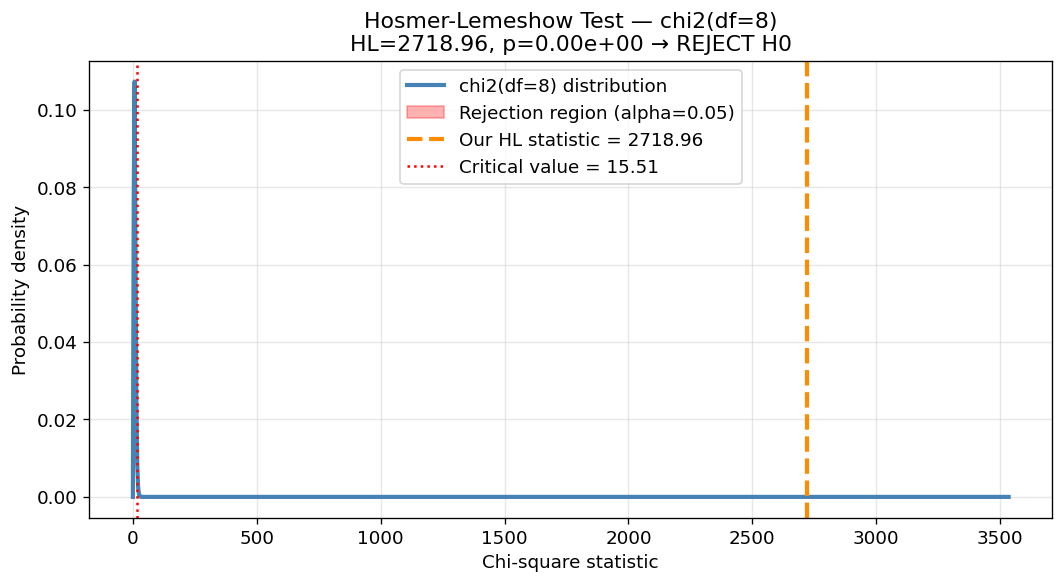

Saved: outputs/plots/03_hosmer_lemeshow.png


In [8]:
# Plot: where does our HL statistic fall on the chi-square distribution?
# This visualises how extreme our result is
fig, ax = plt.subplots(figsize=(9, 5))

# Draw the chi-square distribution curve for our degrees of freedom
x = np.linspace(0, max(hl_stat * 1.3, 30), 1000)
y = chi2.pdf(x, df=df_hl)

ax.plot(x, y, "steelblue", linewidth=2.5, label=f"chi2(df={df_hl}) distribution")

# Shade the critical region (right tail beyond alpha=0.05)
critical_value = chi2.ppf(1 - ALPHA, df=df_hl)
tail_x = x[x >= critical_value]
tail_y = y[x >= critical_value]
ax.fill_between(tail_x, tail_y, alpha=0.3, color="red",
                label=f"Rejection region (alpha={ALPHA})")

# Mark our test statistic — if it falls in red zone we reject H0
ax.axvline(hl_stat, color="darkorange", linewidth=2.5, linestyle="--",
           label=f"Our HL statistic = {hl_stat:.2f}")
ax.axvline(critical_value, color="red", linewidth=1.5, linestyle=":",
           label=f"Critical value = {critical_value:.2f}")

ax.set_xlabel("Chi-square statistic")
ax.set_ylabel("Probability density")
ax.set_title(f"Hosmer-Lemeshow Test — chi2(df={df_hl})\n"
             f"HL={hl_stat:.2f}, p={p_value:.2e} → {decision}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/plots/03_hosmer_lemeshow.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/03_hosmer_lemeshow.png")